# Tree Model Training & Test (LOIO-CV)

## 传统树模型（随机森林 / XGBoost / LightGBM）的留一交叉验证训练与测试

本代码使用手工提取的 119 个特征，对随机森林、XGBoost 和 LightGBM 三种树模型进行 留一个体交叉验证（LOIO‑CV）。支持 SMOTE 过采样缓解类别不平衡，训练后保存模型、特征重要性、预测结果及混淆矩阵。该实现对应论文第 2.6 节与第 3.3 节（图 6、图 7、图 S12–S14），用于量化经典机器学习方法与深度学习模型的性能差距

u## Import Modules

In [ ]:
# =============================================================================
# Cell 作用：导入运行整个 notebook 所需的所有第三方库与项目内部模块，
# 并完成日志、绘图风格、pandas 显示参数等全局配置。
# =============================================================================

import os                                          # 操作系统相关库，用于路径管理、文件搜索等
import time                                        # 计时库，用于统计程序运行时间
import glob                                        # 文件匹配库，例如批量读取 csv 文件
import pickle                                      # Python 对象序列化与反序列化（保存训练好的模型）
import logging                                     # 标准日志库
from logging import getLogger, basicConfig, INFO   # 日志快捷接口
from pathlib import Path                           # 面向对象的路径操作

import numpy as np                                 # 数值计算
import pandas as pd                                # 表格数据处理
import matplotlib.pyplot as plt                     # 绘图库（用于可视化、混淆矩阵、F1-score 图等）

# 机器学习相关
from sklearn.model_selection import train_test_split   # 训练集 / 验证集划分
from imblearn.over_sampling import SMOTE               # 不平衡样本上采样
from sklearn.ensemble import RandomForestClassifier    # 随机森林模型
import xgboost as xgb                                  # XGBoost 模型
import lightgbm as lgb                                 # LightGBM 模型
from lightgbm.callback import _format_eval_result      # LightGBM 训练日志格式化

# Hydra/OmegaConf：用来加载 YAML 配置（本 notebook 复刻了 Hydra 的合并逻辑）
from omegaconf import DictConfig, OmegaConf

# 让 notebook 能 import 上一层目录的 src 包
import sys
sys.path.append("../")  # parent dir so `from src import ...` works
sys.dont_write_bytecode = True                     # 不生成 .pyc 文件，避免污染源码目录
%load_ext autoreload                                # 自动重载已修改的模块
%autoreload 2

# 项目内部工具：环境/随机种子工具 + 通用工具函数
from src import env
from src import utils

# 设置 matplotlib 全局风格 + 取得色盲友好调色板
(
    plot_parameters, okabe_ito_color_list, tol_bright_color_list
) = utils.setup_plot(show_color_palette=False)

# 配置日志输出格式（INFO 级别，带等级前缀）
basicConfig(level=INFO, format="[%(levelname)s] %(message)s")
log = getLogger(__name__)
logging.getLogger('matplotlib').setLevel(logging.INFO)  # 抑制 matplotlib 的 DEBUG 日志

# pandas 显示选项：让 DataFrame 在 notebook 中尽量完整展示
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Load Config

Original script uses Hydra. Here we load `config_tree.yaml` directly, register a custom `hydra` resolver so `${hydra:runtime.cwd}` in `path.yaml` resolves to the project root, and recursively merge the `defaults:` group entries.

In [ ]:
# =============================================================================
# Cell 作用：定位本次实验要使用的主配置文件路径（config_tree.yaml）。
# 后续 cell 会基于该路径加载完整 Hydra 配置。
# =============================================================================

CONFIG_DIR = Path("../configs").resolve()          # 项目 configs 目录的绝对路径
config_path = CONFIG_DIR / "config_tree.yaml"      # 树模型主配置文件
print(f"config_path: {config_path}")

In [ ]:
# =============================================================================
# Cell 作用：加载 Hydra 风格的 YAML 配置。
#
# 由于本 notebook 没有真正使用 Hydra 装饰器（@hydra.main），所以我们：
#   1) 手动注册一个名为 "hydra" 的 OmegaConf resolver，让配置中的
#      ${hydra:runtime.cwd} 占位符能解析到项目根目录；
#   2) 写一个 load_hydra_config()，递归合并 defaults: 中引用的子配置；
#   3) 跳过属于 Hydra 自身运行时的 hydra/* 配置组（与本 notebook 无关）。
# 最终把扁平化合并后的 cfg 打印出来，方便检查所有超参数。
# =============================================================================

PROJECT_ROOT = Path("../").resolve()               # 项目根目录绝对路径

# 注册自定义解析器：让 ${hydra:runtime.cwd} 解析为项目根目录字符串
if not OmegaConf.has_resolver("hydra"):
    OmegaConf.register_new_resolver(
        "hydra",
        lambda key: str(PROJECT_ROOT) if key == "runtime.cwd" else ""
    )

def load_hydra_config(config_path: Path, config_dir: Path) -> DictConfig:
    """加载 Hydra 风格的配置：顶层 YAML + defaults 中的子配置（递归合并）。

    会跳过 hydra/ 命名空间下的组（例如 `override hydra/job_logging`），
    因为这些是 Hydra 自己的运行时配置，依赖只有在 Hydra 装饰器下才存在
    的 resolver（如 ${hydra.run.dir}）。
    """
    base = OmegaConf.load(config_path)                              # 加载顶层 yaml
    merged = OmegaConf.create({})                                   # 用来累计合并结果的空 cfg
    defaults = base.pop("defaults", []) if "defaults" in base else []  # 取出 defaults: 列表

    # 遍历 defaults: 列表
    for entry in defaults:
        if isinstance(entry, str):
            # 字符串型条目（如 "_self_" 或一个 yaml 名字）
            if entry in ("_self_",):
                continue                                            # 跳过 _self_ 占位符
            sub_path = config_dir / f"{entry}.yaml"                 # 拼出子文件路径
            if sub_path.exists():
                merged = OmegaConf.merge(merged, OmegaConf.load(sub_path))
        elif isinstance(entry, (dict, DictConfig)):
            # 字典型条目，如 {dataset: om} 表示读取 dataset/om.yaml
            for group, name in dict(entry).items():
                if name is None:
                    continue
                group_clean = str(group).replace("override ", "")   # 移除 "override " 前缀
                # 跳过 Hydra 自身配置组
                if group_clean == "hydra" or group_clean.startswith("hydra/"):
                    continue
                sub_path = config_dir / group_clean / f"{name}.yaml"
                if sub_path.exists():
                    merged = OmegaConf.merge(
                        merged,
                        {group_clean: OmegaConf.load(sub_path)}
                    )
    # 最后把顶层 yaml 的剩余字段合并进来（顶层优先级最高）
    merged = OmegaConf.merge(merged, base)
    if "hydra" in merged:
        del merged["hydra"]                                         # 删掉 hydra 命名空间
    return merged

# 实际加载配置 + 打印（resolve=True 会把 ${...} 占位符展开成真实值）
cfg = load_hydra_config(config_path, CONFIG_DIR)
print(OmegaConf.to_yaml(cfg, resolve=True))

### Optional overrides

In [ ]:
# =============================================================================
# Cell 作用：可选的临时覆盖（overrides）。
# 在不修改 yaml 文件的前提下，临时改某些超参数做调试或切换实验。
# 默认全部注释掉，相当于"不覆盖"。
# =============================================================================

# cfg.debug = True                       # 调试模式：只跑 1 折 LOIO-CV，n_estimators 也会被改小
# cfg.model.model_name = "lightgbm"      # 切换树模型类型：random-forest / xgboost / lightgbm
# cfg.train.smote = False                # 关闭 SMOTE 上采样
# cfg.train.n_estimators = 1000          # 降低树的数量以加速调试
pass

## Helpers (data prep, fitting, logging callbacks, save)

In [ ]:
# =============================================================================
# Cell 作用：定义本 notebook 训练流程会用到的所有 helper（辅助函数 / 回调类）。
#
# 共 5 个工具：
#   1) XGBLogging          —— XGBoost 训练回调，每 N 个 epoch 打一行日志。
#   2) lgb_log_evaluation  —— LightGBM 训练日志回调（用 logging 模块输出）。
#   3) setup_data_ml       —— 读取并拼接所有个体的特征 CSV，得到完整 df。
#   4) prep_train_val_test_data_ml —— 按 LOIO-CV 划分训练/验证/测试集 + 可选 SMOTE。
#   5) fit_tree_models     —— 按 cfg.model.model_name 训练 RF / XGBoost / LightGBM。
#   6) save_tree_model     —— 把训练好的模型 pickle 到 log 目录。
# =============================================================================


class XGBLogging(xgb.callback.TrainingCallback):
    """XGBoost 训练回调：把训练日志每隔 epoch_log_interval 写一次。"""

    def __init__(self, epoch_log_interval=100):
        self.epoch_log_interval = epoch_log_interval

    def after_iteration(self, model, epoch, evals_log):
        # 每隔 epoch_log_interval 轮记录一次评估指标
        if epoch % self.epoch_log_interval == 0:
            for data, metric in evals_log.items():
                metrics = list(metric.keys())
                metrics_str = ""
                for m_key in metrics:
                    metrics_str = metrics_str + f"{m_key}: {metric[m_key][-1]}"
                log.info(f"Epoch: {str(epoch).zfill(4)}, {data}: {metrics_str}")
        return False  # 返回 False 表示不提前停训


def lgb_log_evaluation(logger, period=1, show_stdv=True, level=logging.DEBUG):
    """生成 LightGBM 的日志回调函数：每 period 轮打印一次评估指标。"""
    def _callback(env):
        # env 是 LightGBM 传给回调的训练上下文
        if period > 0 and env.evaluation_result_list and (env.iteration + 1) % period == 0:
            result = '\t'.join([_format_eval_result(x, show_stdv) for x in env.evaluation_result_list])
            logger.log(level, '[{}]\t{}'.format(str(env.iteration + 1).zfill(3), result))
    _callback.order = 10
    return _callback


def setup_data_ml(cfg):
    """读取数据：把指定物种文件夹下所有特征 CSV 合并成一个大 DataFrame。

    返回 (df, df_sampled)：当前实现里两者相同（dataset_amount=100%），
    但保留两个返回值以兼容原脚本接口（df 用作 test，df_sampled 用作 train/val）。
    """
    # 把简写的物种代码（om/um）映射到完整的文件夹名
    if cfg.dataset.species == "om":
        species_dir = "omizunagidori"             # 大水薙鸟（Streaked Shearwater）
    elif cfg.dataset.species == "um":
        species_dir = "umineko"                   # 黑尾鸥（Black-tailed Gull）

    # 拼接特征 CSV 所在目录，并匹配所有 csv 文件
    data_dir = os.path.join(cfg.path.nas.rootdir, "data")
    base_target = f"{data_dir}/datasets/logbot_data/feature_extraction/acc_features"
    target = f"{base_target}/{species_dir}/*.csv"
    features_data_path_list = sorted(glob.glob(target))

    # 逐个体读取并 concat 到同一个 DataFrame
    df = pd.DataFrame()
    for features_data_path in features_data_path_list:
        df_tmp = pd.read_csv(features_data_path)
        df = pd.concat([df, df_tmp])

    # 这里保留按比例采样的接口；当前实验固定 100%
    dataset_amount = 100
    log.info(f'Dataset amount: {dataset_amount}%')
    if dataset_amount == 100:
        df_sampled = df
    else:
        raise Exception(f"dataset_amount: {dataset_amount} is not accepted.")

    log.info(f'N of instances (df): {len(df)}')
    log.info(f'N of instances (df_sampled): {len(df_sampled)}')
    log.info(f"df: \n{df['label_id_int'].value_counts().sort_index()}")

    # 只保留：动物 ID、时间戳、标签 + 配置里列出的特征列
    usecols = ['animal_id', 'unixtime', 'label_id_int'] + list(cfg.features.features_list)
    df = df[usecols]
    df_sampled = df_sampled[usecols]
    return df, df_sampled


def prep_train_val_test_data_ml(cfg, df, df_sampled,
                                X_drop_col_list, label_target,
                                train_animal_id_list, val_animal_id_list, test_animal_id_list,
                                smote=True):
    """按 LOIO-CV 的个体划分构造 train / val / test：
        - test 集：测试个体的所有样本
        - train+val 集：剩余个体的样本，按 8:2 分层抽样
        - 可选 SMOTE：对训练集做少数类上采样
    """
    # ---------- 测试集 ----------
    df_test = df[df["animal_id"].isin(test_animal_id_list)]
    X_test = df_test.drop(X_drop_col_list, axis=1)           # 去掉非特征列
    y_test = df_test[label_target]                            # 标签列

    # ---------- 训练 + 验证集 ----------
    df_train_val = df_sampled[df_sampled["animal_id"].isin(train_animal_id_list)]
    log.info(f"len(df_train_val): {len(df_train_val)}")
    X_df = df_train_val.drop(X_drop_col_list, axis=1)
    y_s = df_train_val[label_target]

    # 8:2 分层抽样，使训练/验证集的类别比例一致
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_df, y_s,
        test_size=0.2,
        random_state=cfg.seed,
        stratify=y_s
    )
    log.info(f"y_train.shape: {y_train.shape}")
    log.info(f"y_train: \n{y_train.value_counts().sort_index()}")
    log.info(f'X_train.shape: {X_train.shape}')
    log.info(f'X_valid.shape: {X_valid.shape}')

    # ---------- 可选 SMOTE 上采样 ----------
    # 注意：只对训练集做 SMOTE，验证集和测试集保持原始分布
    if smote == True:
        sm = SMOTE(random_state=cfg.seed, k_neighbors=cfg.train.smote_k_neighbors)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        log.info("| Applied SMOTE |")
        log.info(f"y_train (SMOTE): \n{y_train.value_counts().sort_index()}")
        log.info(f'X_train.shape: {X_train.shape}')
        log.info(f'X_valid.shape: {X_valid.shape}')

    return X_train, X_valid, X_test, y_train, y_valid, y_test


def fit_tree_models(cfg, logger, X_train, X_valid, y_train, y_valid):
    """根据 cfg.model.model_name 训练对应的树模型。
    支持三种：random-forest / xgboost / lightgbm。
    """
    if cfg.model.model_name == "random-forest":
        # ------------------- 随机森林 -------------------
        model = RandomForestClassifier(
            class_weight="balanced",       # 内置类别加权，弥补不平衡
            n_estimators=500,
            max_depth=6,
            random_state=cfg.seed,
        )
        model.fit(X_train, y_train)
    elif cfg.model.model_name == "xgboost":
        # ------------------- XGBoost -------------------
        params = {
            'objective': 'multi:softprob',          # 多分类概率输出
            'eval_metric': 'mlogloss',              # 多类对数损失
            'booster': 'gbtree',
            'n_estimators': cfg.train.n_estimators,
            'early_stopping_rounds': 10,            # 验证集 10 轮不提升即停
            'callbacks': [XGBLogging(epoch_log_interval=100)],
            'learning_rate': 0.01,
            'max_depth': 6,
            'random_state': cfg.seed,
            'verbosity': 0,
            'tree_method': 'hist',                   # CPU 直方图算法（可换成 'gpu_hist' 用 GPU）
        }
        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            verbose=False,
        )
        # 画训练 / 验证 loss 曲线
        results = model.evals_result()
        plt.figure(figsize=(6, 4))
        plt.plot(results["validation_0"]["mlogloss"], label="Training loss")
        plt.plot(results["validation_1"]["mlogloss"], label="Validation loss")
        plt.xlabel("Number of estimators")
        plt.ylabel("mlogloss")
        plt.legend()
        plt.show()
        plt.close()
    elif cfg.model.model_name == "lightgbm":
        # ------------------- LightGBM -------------------
        lgb.register_logger(logger)                 # 把项目 logger 注册到 lightgbm
        params = {
            'objective': 'multiclass',
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            'n_estimators': cfg.train.n_estimators,
            'learning_rate': 0.01,
            'random_state': cfg.seed,
        }
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_valid, y_valid)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=10, verbose=True),
                lgb_log_evaluation(logger, period=50)
            ]
        )
        # 画 LightGBM 内置的指标曲线
        plt.rcParams["figure.figsize"] = (6, 4)
        lgb.plot_metric(model)
        plt.show()
        plt.close()
    else:
        raise Exception(f'cfg.model.model_name "{cfg.model.model_name}" is not appropriate.')
    return model


def save_tree_model(cfg, logger, model, test_animal_id):
    """把训练好的模型 pickle 到 log 目录，文件名 = 该折的测试个体 ID。"""
    path = Path(cfg.path.log.rootdir, f"{test_animal_id}.pickle")
    logger.debug(f"model pickle file path: {path}")
    path.parent.mkdir(parents=True, exist_ok=True)        # 目录不存在则创建
    with open(path, mode='wb') as f:
        pickle.dump(model, f, protocol=2)                  # protocol=2 兼容性更好

## Setup: sanity checks, save config, seed

In [ ]:
# =============================================================================
# Cell 作用：训练前的一些准备工作 ——
#   1) 推断物种文件夹名；
#   2) 一致性检查：SMOTE 开关 vs SMOTE 目录名必须匹配；
#   3) 把当前 cfg 保存到 log 目录，便于复现；
#   4) 固定随机种子，让结果可复现；
#   5) 打印特征数量等 sanity-check 信息。
# =============================================================================

# 1) 物种代码 -> 文件夹名
if cfg.dataset.species == "om":
    species_dir = "omizunagidori"
elif cfg.dataset.species == "um":
    species_dir = "umineko"

# 2) 一致性检查：如果关掉了 SMOTE 却仍把目录名标成 smote-true，结果文件会被误归类
if cfg.train.smote == False and cfg.train.smote_dir_name == "smote-true":
    raise Exception(
        f"check config file -> cfg.train.smote: {cfg.train.smote} | "
        f"cfg.train.smote_dir_name: {cfg.train.smote_dir_name}"
    )

# 3) 把本次实验的 cfg dump 到 log 目录里（用于事后复盘）
save_config_path = os.path.join(cfg.path.log.rootdir, "config.yaml")
if not os.path.exists(cfg.path.log.rootdir):
    os.makedirs(cfg.path.log.rootdir)
OmegaConf.save(cfg, save_config_path)
log.info(f"cfg.path.log.rootdir : {cfg.path.log.rootdir}")
log.info(f"cfg.seed: {cfg.seed}")

# 4) 固定 numpy / random 等的随机种子，保证训练可复现
env.reset_seed_ml(int(cfg.seed))

# 5) 打印特征信息便于核对
n_features = len(cfg.features.features_list)
log.info(f"n_features: {n_features}")
features = cfg.features
log.info(f"features: {features}")

## Load + NaN-fill data

In [ ]:
# =============================================================================
# Cell 作用：实际触发数据加载，并处理空值。
#   - 调用 setup_data_ml(cfg)：拼接所有个体的特征 CSV。
#   - 用 0 填充 NaN（原数据中如 OM2103 的 ODBA_mean/var/max 可能含 NaN）。
#   - 展示前 3 行 sanity-check。
# =============================================================================

df, df_sampled = setup_data_ml(cfg)                # 读取并合并所有特征 CSV
df = df.fillna(0)                                   # 用 0 填充 NaN（避免树模型/SMOTE 出错）
df_sampled = df_sampled.fillna(0)
df.head(3)                                          # 展示前 3 行做 sanity-check

In [ ]:
# =============================================================================
# Cell 作用：诊断 cell —— 在跑 LOIO-CV 之前快速验证：
#   1) df 是否真的加载到了样本；
#   2) df['animal_id'] 中出现的个体 ID，和 cfg 里配置的 train/test 个体 ID 能否对上；
#   3) 第一折（first fold）的训练/测试集是否都能匹配到行。
#
# 这步看似多余，但如果配置里写错了一个个体 ID，
# 后面 LOIO-CV 跑出来会"全空 train_set"或"全空 test_set"，浪费几十分钟。
# =============================================================================

# --- DIAGNOSTIC: verify dataset is loaded and animal IDs match before LOIO-CV ---
print(f"df shape: {df.shape}")                                          # 行列数
print(f"df.columns (first 10): {list(df.columns)[:10]}")                # 前 10 列名
print(f"df unique animal_id (sample): {df['animal_id'].unique()[:5]}")  # 前 5 个个体 ID
print(f"df['animal_id'].nunique(): {df['animal_id'].nunique()}")        # 个体总数

# 取第一折（list_list 的第 0 个元素就是第一折的 test 个体集合）
first_fold = list(cfg.dataset.labelled.test_animal_id_list_list)[0]
print(f"\nfirst fold test_animal_id_list: {first_fold}")

# 用 utils 的接口推导出该折的 train / val / test 个体列表
(
    train_animal_id_list,
    val_animal_id_list,
    test_animal_id_list
) = utils.setup_train_val_test_animal_id_list(cfg, list(first_fold))
print(f"train ids ({len(train_animal_id_list)}): {train_animal_id_list[:5]} ...")
print(f"val   ids ({len(val_animal_id_list)}): {val_animal_id_list}")
print(f"test  ids ({len(test_animal_id_list)}): {test_animal_id_list}")

# 实际去 df 里筛选行数，校验 ID 是否对得上
df_test_check = df[df['animal_id'].isin(test_animal_id_list)]
df_train_check = df[df['animal_id'].isin(train_animal_id_list)]
print(f"\nrows matched for test ids: {len(df_test_check)}")
print(f"rows matched for train ids: {len(df_train_check)}")

# 若行数为 0，说明配置中的 ID 和 CSV 中的 ID 拼写不一致 —— 必须先修
if len(df_train_check) == 0:
    print(">>> No training rows! df['animal_id'] values likely don't match the IDs in dataset config.")
if len(df_test_check) == 0:
    print(">>> No test rows for first fold! Same root cause likely.")

## LOIO-CV training loop

In [ ]:
# =============================================================================
# Cell 作用：LOIO-CV (Leave-One-Individual-Out Cross Validation) 主训练循环。
#
# 流程：
#   1) 准备容器（y_gt_all / y_pred_all / test_animal_id_all 用来汇总所有折结果，
#      importances 用来累加每折的特征重要性）。
#   2) 如果是 debug 模式，只跑一折，减少调试时间。
#   3) 对 test_animal_id_list_list 中的每个测试个体集合：
#        - 推导出训练 / 验证 / 测试个体；
#        - 调用 prep_train_val_test_data_ml() 构造数据集（可选 SMOTE）；
#        - 调用 fit_tree_models() 训练模型；
#        - 把模型 pickle 到 log 目录；
#        - 累加 feature_importances；
#        - 在测试个体上预测，把 (y_gt, y_pred) 加入全局列表。
#
# 数据量：om 物种共 28 个个体 -> 28 折 -> 总耗时约 50 min。
# =============================================================================

#该模块需要跑28个图，用时50min左右
y_gt_all = []                          # 所有折的真实标签（按出现顺序拼起来）
y_pred_all = []                        # 所有折的预测标签
test_animal_id_all = []                # 与 y_gt_all 一一对应，记录每个样本来自哪个 test fold
model_name = cfg.model.model_name
test_animal_id_list_list = cfg.dataset.labelled.test_animal_id_list_list
importances = None                     # 累加器：拼接每折的 model.feature_importances_

# ---- debug 模式：只跑 1 折 + n_estimators 调小到 100，方便快速验证流程 ----
if cfg.debug == True:
    if cfg.dataset.species == "om":
        test_animal_id_list = ["OM2101"]
    elif cfg.dataset.species == "um":
        test_animal_id_list = ["UM1901"]
    test_animal_id_list_list = [test_animal_id_list]
    cfg.train.n_estimators = 100

# ---------- 逐折训练 ----------
for test_animal_id_list in test_animal_id_list_list:
    log.info("------------------------------------------------------------------------------------------")
    log.info(f"test_animal_id_list: {test_animal_id_list}")
    test_animal_id = test_animal_id_list[0]      # 该折的代表性测试个体 ID（用作文件名）

    # 推导该折的 train / val / test 个体 ID 列表
    (
        train_animal_id_list,
        val_animal_id_list,
        test_animal_id_list
    ) = utils.setup_train_val_test_animal_id_list(cfg, test_animal_id_list)

    # 构造 X/y：去掉 animal_id/unixtime/label_id_int 这些非特征列
    X_drop_col_list = ['animal_id', 'unixtime', 'label_id_int']
    label_target = 'label_id_int'
    (
        X_train, X_valid, X_test,
        y_train, y_valid, y_test
    ) = prep_train_val_test_data_ml(
        cfg, df, df_sampled,
        X_drop_col_list, label_target,
        train_animal_id_list, val_animal_id_list, test_animal_id_list,
        smote=cfg.train.smote,
    )

    # 训练 + 保存模型，并计时
    start_time = time.time()
    model = fit_tree_models(cfg, log, X_train, X_valid, y_train, y_valid)
    save_tree_model(cfg, log, model, test_animal_id)
    elapsed_time = time.time() - start_time
    log.info(f"Elapsed time: {elapsed_time:.3f} seconds")

    # 累加特征重要性（最终长度 = n_features * n_folds）
    if importances is None:
        importances = model.feature_importances_
    else:
        importances = np.concatenate([importances, model.feature_importances_])

    # 在该折的测试个体上做预测，并把 (gt, pred) 累入全局结果
    y_gt, y_pred = y_test, model.predict(X_test)
    y_gt_all.extend(y_gt)
    y_pred_all.extend(y_pred)
    test_animal_id_all.extend([test_animal_id_list] * len(y_gt))

## Save outputs: feature importances, test scores, predictions, confusion matrix

In [ ]:
# =============================================================================
# Cell 作用：根据 cfg 构造结果保存的目录路径与文件名前缀。
# 不实际写文件，只是把字符串准备好，后续 save-importances / save-scores /
# save-cm 三个 cell 会用到这些路径。
# =============================================================================

# 文件名片段：模型名_物种_特征集_smote_seed
fname1 = f"{cfg.model.model_name}"
fname2 = f"{cfg.dataset.species}"      # ML 流程下 source = target，直接用物种名
fname3 = f"seed{cfg.seed}"

# 这里再次根据 smote 开关刷新一次目录名，确保和实际开关一致
cfg.train.smote_dir_name = "smote-true" if cfg.train.smote == True else "smote-false"

# 完整文件名前缀（小写 + 把 '-' 替换为 '_' 避免文件名怪异）
file_name_base = (
    f"{fname1}_{fname2}_feats_{cfg.features.features_set_name}_"
    f"{cfg.train.smote_dir_name}_{fname3}"
).lower().replace("-", "_")

test_animal_id = "LOIOCV_ALL"          # 汇总结果的"测试 ID"占位符

# 拼接保存根目录：data/test-results/{issue}/{ex}/{species-window}/{model}/{model-feats-smote}
data_dir = os.path.join(cfg.path.nas.rootdir, "data")
base_dir = (
    f"{data_dir}/test-results/{cfg.issue}/{cfg.ex}/"
    f"{cfg.dataset.species}-{cfg.dataset.window_size}/{cfg.model.model_name}"
)
results_base_dir = (
    f"{base_dir}/{cfg.model.model_name}-feats-"
    f"{cfg.features.features_set_name}-{cfg.train.smote_dir_name}"
)
log.info(f"results_base_dir: {results_base_dir}")
log.info(f"file_name_base: {file_name_base}")

In [ ]:
# =============================================================================
# Cell 作用：把 LOIO-CV 所有折的 feature_importances 整理成长表并保存为 CSV。
# 输出列：['features', 'importances']，行数 = n_features * n_folds。
# 之所以做成长表（而不是 [features × folds] 的宽表），是为了让 seaborn/ggplot
# 直接用 hue=features 画各折分布更方便。
# =============================================================================

# feature importances
# 防御性检查：如果 LOIO-CV 一折都没跑（importances 还是 None），
# 直接保存会失败 —— 这里先抛错并提示用户回去看 loiocv cell 的输出。
if importances is None:
    raise RuntimeError(
        "`importances` is None — the LOIO-CV loop did not complete any fold.\n"
        f"  len(test_animal_id_list_list) = {len(test_animal_id_list_list)}\n"
        f"  len(y_gt_all) = {len(y_gt_all)}\n"
        "Re-run the `loiocv` cell and check its output for errors."
    )

# 重要性数组长度 = n_features × n_folds，反推出 n_folds
n_features_used = len(features['features_list'])
n_folds = int(importances.shape[0] / n_features_used)
log.info(f"N of LOIO-CV folds: {importances.shape[0] / n_features_used}")

# 构造长表 DataFrame
data_dict = {
    'features': list(features['features_list']) * n_folds,   # 特征名按折重复
    'importances': importances,                              # 每折每个特征的重要性
}
df_importance = pd.DataFrame(data_dict)

# 写文件：保存到 {results_base_dir}/feature-importances/feature_importances_xxx.csv
importance_save_dir = f"{results_base_dir}/feature-importances"
os.makedirs(importance_save_dir, exist_ok=True)
importance_save_path = f"{importance_save_dir}/feature_importances_{file_name_base}.csv"
df_importance.to_csv(importance_save_path, index=False)
print(f"saved: {importance_save_path}")

CSV列名： ['features', 'importances']
数据形状： (3332, 2)
     features  importances
0  acc_x_mean     0.001789
1  acc_y_mean     0.001511
2  acc_z_mean     0.026829
3   acc_x_var     0.002758
4   acc_y_var     0.002429

特征重要性排名前20：
 rank         features  mean_importance  std_importance  median_importance  n_folds
    1   acc_x_dcp_mean         0.137166        0.019927           0.133993       28
    2       VeDBA_mean         0.108623        0.047582           0.107118       28
    3        VeDBA_var         0.079259        0.042031           0.066578       28
    4         roll_var         0.049997        0.005984           0.049465       28
    5        acc_z_max         0.045745        0.005130           0.044740       28
    6        pitch_var         0.045459        0.004016           0.045680       28
    7   acc_z_dcp_mean         0.045325        0.014744           0.044745       28
    8        acc_z_min         0.034707        0.012286           0.035751       28
    9   acc_y_dcp_

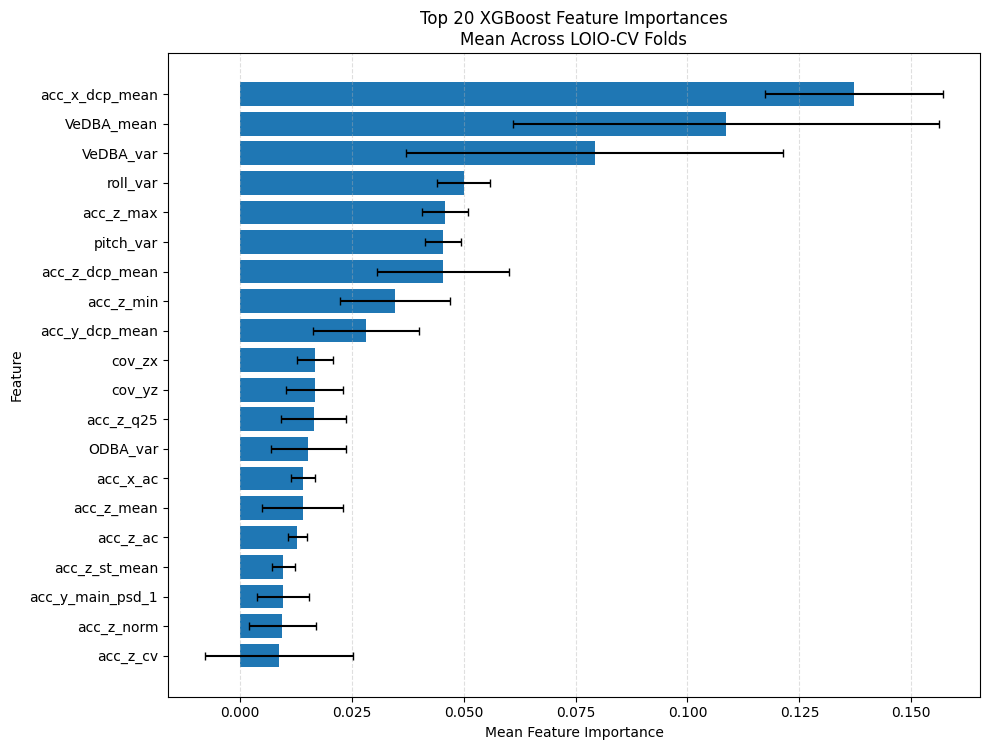


特征重要性图片保存至：
D:\dl-wabc\data\test-results\I03\ex-d90\om-50\xgboost\xgboost-feats-119-smote-true\feature-importances\top20_feature_importance_xgboost_seed0.png


In [1]:
#这里增加了重要性排序图的绘制
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ==============================
# 1. 文件路径
# ==============================
csv_path = Path(
    r"D:\dl-wabc\data\test-results\I03\ex-d90\om-50\xgboost"
    r"\xgboost-feats-119-smote-true\feature-importances"
    r"\feature_importances_xgboost_om_feats_119_smote_true_seed0.csv"
)

if not csv_path.exists():
    raise FileNotFoundError(f"找不到文件：\n{csv_path}")


# ==============================
# 2. 读取数据
# ==============================
df = pd.read_csv(csv_path)

# 清理列名两侧空格
df.columns = df.columns.str.strip()

print("CSV列名：", df.columns.tolist())
print("数据形状：", df.shape)
print(df.head())


# ==============================
# 3. 检查需要的列
# ==============================
feature_col = "features"
importance_col = "importances"

required_columns = {feature_col, importance_col}

if not required_columns.issubset(df.columns):
    raise ValueError(
        "CSV中缺少必要列。\n"
        f"需要的列：{sorted(required_columns)}\n"
        f"实际列：{df.columns.tolist()}"
    )

# 将重要性转换为数值，无法转换的内容设为NaN
df[importance_col] = pd.to_numeric(
    df[importance_col],
    errors="coerce"
)

# 删除特征名称或重要性为空的记录
df = df.dropna(
    subset=[feature_col, importance_col]
)


# ==============================
# 4. 汇总28折特征重要性
# ==============================
# 同一个特征在不同LOIO-CV折次中会重复出现，
# 因此计算平均值、标准差、中位数和出现次数
importance_summary = (
    df.groupby(feature_col)[importance_col]
    .agg(
        mean_importance="mean",
        std_importance="std",
        median_importance="median",
        n_folds="count"
    )
    .reset_index()
    .sort_values(
        by="mean_importance",
        ascending=False
    )
)

# 单次出现的特征，其标准差可能为NaN
importance_summary["std_importance"] = (
    importance_summary["std_importance"].fillna(0)
)

# 添加排名
importance_summary.insert(
    0,
    "rank",
    range(1, len(importance_summary) + 1)
)

print("\n特征重要性排名前20：")
print(importance_summary.head(20).to_string(index=False))


# ==============================
# 5. 保存完整排序结果
# ==============================
ranking_save_path = (
    csv_path.parent
    / "feature_importance_ranking_mean_seed0.csv"
)

importance_summary.to_csv(
    ranking_save_path,
    index=False,
    encoding="utf-8-sig"
)

print("\n完整排名保存至：")
print(ranking_save_path)


# ==============================
# 6. 绘制Top 20特征重要性图
# ==============================
TOP_N = 20

top_features = (
    importance_summary
    .head(TOP_N)
    .sort_values(
        by="mean_importance",
        ascending=True
    )
)

fig_height = max(6, TOP_N * 0.38)

plt.figure(figsize=(10, fig_height))

plt.barh(
    top_features[feature_col],
    top_features["mean_importance"],
    xerr=top_features["std_importance"],
    capsize=3
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 20 XGBoost Feature Importances\n"
    "Mean Across LOIO-CV Folds"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()


# ==============================
# 7. 保存图片
# ==============================
figure_save_path = (
    csv_path.parent
    / "top20_feature_importance_xgboost_seed0.png"
)

plt.savefig(
    figure_save_path,
    dpi=350,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\n特征重要性图片保存至：")
print(figure_save_path)

In [ ]:
# =============================================================================
# Cell 作用：基于 LOIO-CV 全部折的 (y_gt_all, y_pred_all) 计算指标并保存。
# 输出两份 CSV：
#   1) test_score_xxx.csv —— 按类别和 Macro/Weighted 汇总的 Precision/Recall/F1/IoU
#   2) y_gt_y_pred_xxx.csv —— 每个样本的真值/预测/对应 test_id，方便事后细分析
# =============================================================================

# 调用 utils 里的指标函数，得到长表型 score 表
df_test_score_all = utils.generate_test_score_df(cfg, y_gt_all, y_pred_all, test_animal_id)
log.info(f"df_f1_all\n{df_test_score_all}")

# 把样本级别的 (y_gt, y_pred, test_id) 三列拼成表
df_gt_pred_all = pd.DataFrame({
    'y_gt': y_gt_all,
    'y_pred': y_pred_all,
    'test_id': test_animal_id_all,
})

# ---- 保存 test score ----
save_dir = f"{results_base_dir}/test-score"
os.makedirs(save_dir, exist_ok=True)
df_test_score_all.to_csv(f"{save_dir}/test_score_{file_name_base}.csv", index=False)

# ---- 保存样本级 y_gt / y_pred ----
save_dir = f"{results_base_dir}/y-gt-y-pred"
os.makedirs(save_dir, exist_ok=True)
df_gt_pred_all.to_csv(f"{save_dir}/y_gt_y_pred_{file_name_base}.csv", index=False)

print("saved test scores and y_gt/y_pred CSVs")

[INFO] cm_base_dir: C:\Users\bxy11\Desktop\dl-wabc\data/test-results/I03/ex-d90/om-50/xgboost/xgboost-feats-119-smote-true/confusion-matrix/


                 Stationary  Bathing  Take-off  Cruising Flight  Foraging Dive  Dipping
Stationary            18569      127         0               98              7      187
Bathing                 127      599        16               26            109      136
Take-off                  0        5        59               13              0        3
Cruising Flight         265       45        35            20780              6       95
Foraging Dive            30       47         5                2            527       12
Dipping                 376       62         5               47             10       96


[INFO] Saved model outputs.


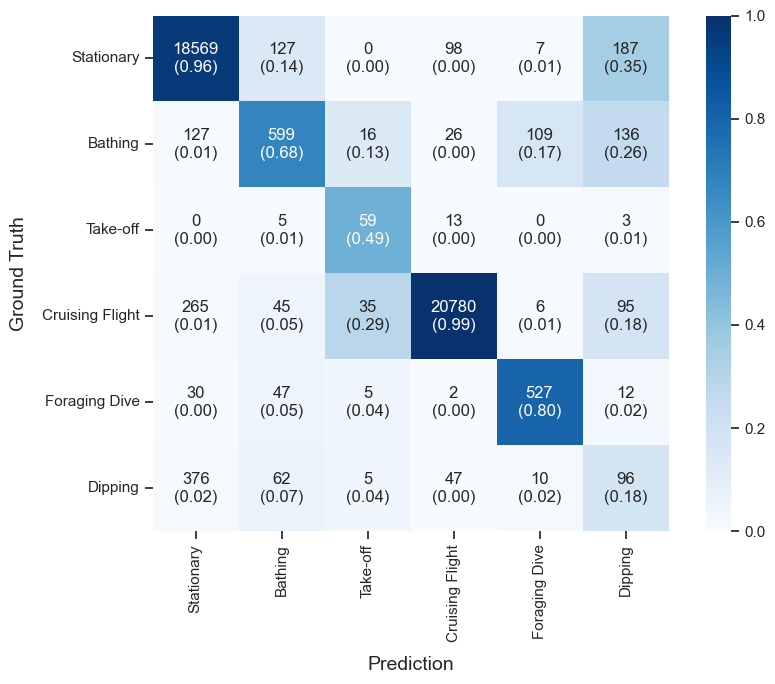

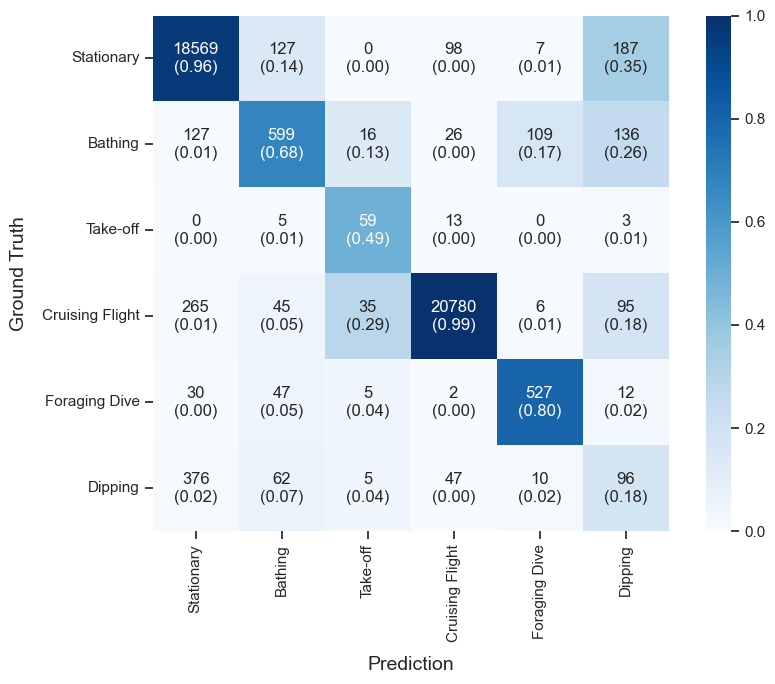

In [13]:
cm_base_dir = f"{results_base_dir}/confusion-matrix/"
log.info(f"cm_base_dir: {cm_base_dir}")
os.makedirs(cm_base_dir, exist_ok=True)
cm, df_cm, fig_cm = utils.plot_confusion_matrix(y_gt_all, y_pred_all, cfg)
fig_cm.savefig(
    f"{cm_base_dir}/confusion_matrix_{file_name_base}.png",
    dpi=350,
    bbox_inches='tight',
    pad_inches=0.15
)
log.info("Saved model outputs.")
fig_cm